Klasifikacija korisnika online prodavnice po sklonosti ka kupovini
Opis: Na osnovu karakteristika kao što su broj poseta sajtu, broj stavki u korpi, prethodne kupovine, prosečno vreme provedeno na sajtu, generiši korisnike koji će kupiti ili neće.

Modeli: Gradient Boosting, SVM, Neural Networks

Dodaci: analiza ponašanja korisnika, dodavanje šuma, balans nebalansiranih klasa

Karakteristika	Tip	Opis
visits	int	Broj poseta sajtu (0–50)
cart_items	int	Broj stavki u korpi (0–20)
past_purchases	int	Broj prethodnih kupovina (0–10)
avg_time_on_site	float	Prosečno vreme na sajtu (u minutima, 0–60)
ad_clicks	int	Broj klikova na reklame (0–30)
referral	binary	Da li je došao sa preporuke (0/1)
purchase	target	0 = nije kupio, 1 = kupio

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("online_store_users.csv")

In [4]:
print(df.head())

   visits  cart_items  past_purchases  avg_time_on_site  ad_clicks  referral  \
0      12           3               3          0.000000          1         0   
1       6           2               3         21.590931          2         0   
2      11           0               2         21.174216          2         0   
3      14           4               1         23.144962          7         0   
4       7           1               7         40.058481          4         0   

   purchase  
0         0  
1         0  
2         0  
3         1  
4         0  


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   visits            10000 non-null  int64  
 1   cart_items        10000 non-null  int64  
 2   past_purchases    10000 non-null  int64  
 3   avg_time_on_site  10000 non-null  float64
 4   ad_clicks         10000 non-null  int64  
 5   referral          10000 non-null  int64  
 6   purchase          10000 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 547.0 KB


In [6]:
df.describe()

,visits,cart_items,past_purchases,avg_time_on_site,ad_clicks,referral,purchase
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,10.018600,1.979800,5.082600,15.337934,2.979100,0.293500,0.253900
std,3.144971,1.409465,3.156291,9.478515,1.709197,0.455388,0.435263
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.000000,1.000000,2.000000,8.246751,2.000000,0.000000,0.000000
50%,10.000000,2.000000,5.000000,15.101435,3.000000,0.000000,0.000000
75%,12.000000,3.000000,8.000000,21.913695,4.000000,1.000000,1.000000
max,24.000000,10.000000,10.000000,52.453792,14.000000,1.000000,1.000000


EDA

In [7]:
print(df['purchase'].value_counts(normalize=True))

purchase
0    0.7461
1    0.2539
Name: proportion, dtype: float64


In [8]:
import seaborn as sns

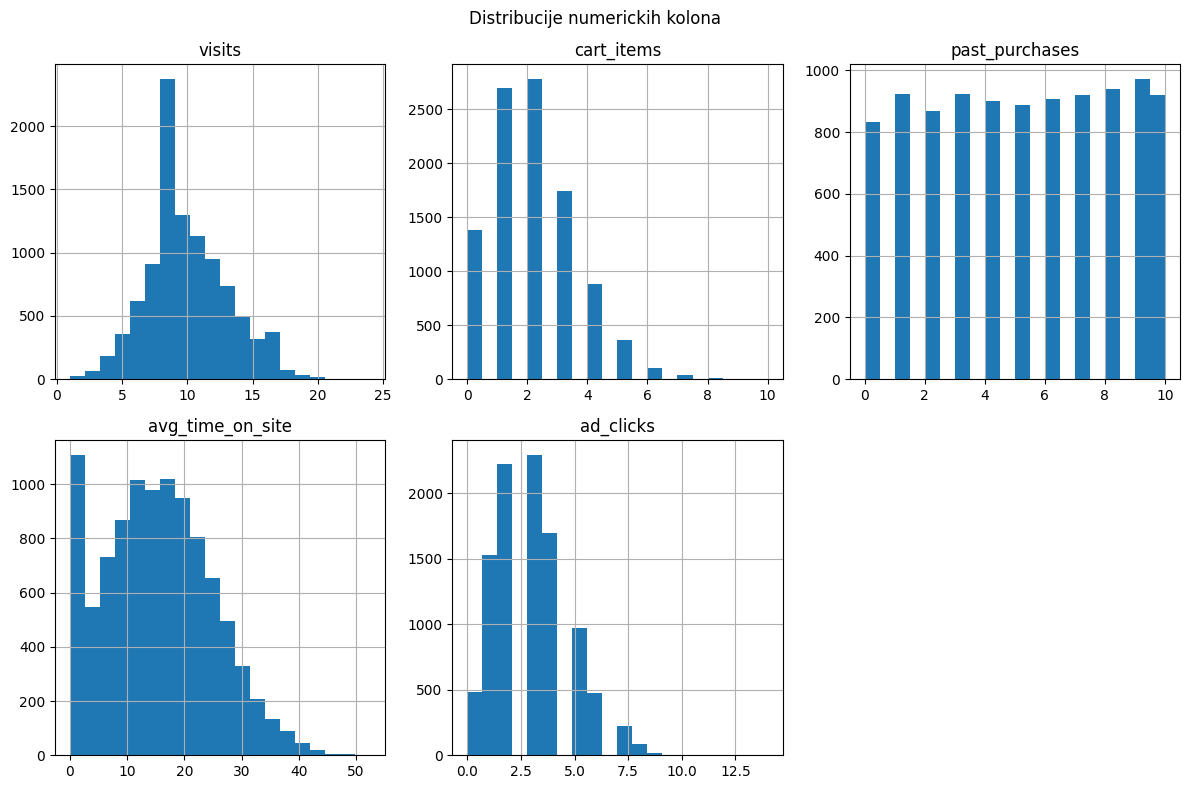

In [9]:
num_cols = ['visits', 'cart_items', 'past_purchases', 'avg_time_on_site','ad_clicks']
df[num_cols].hist(bins=20, figsize=(12,8), layout=(2,3))

plt.suptitle("Distribucije numerickih kolona")
plt.tight_layout()
plt.show()



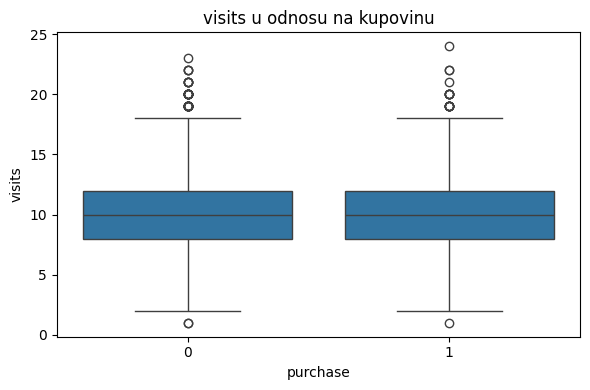

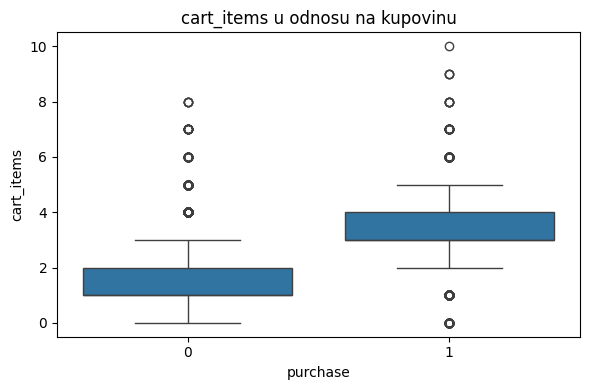

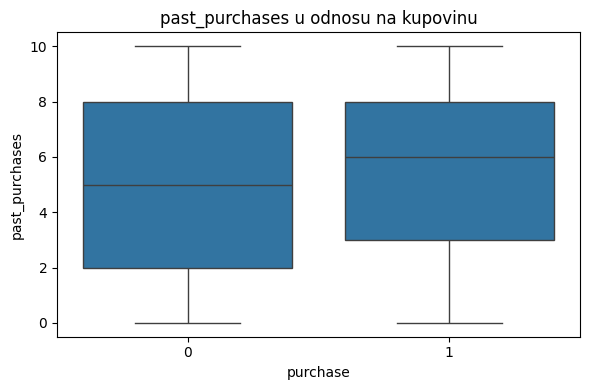

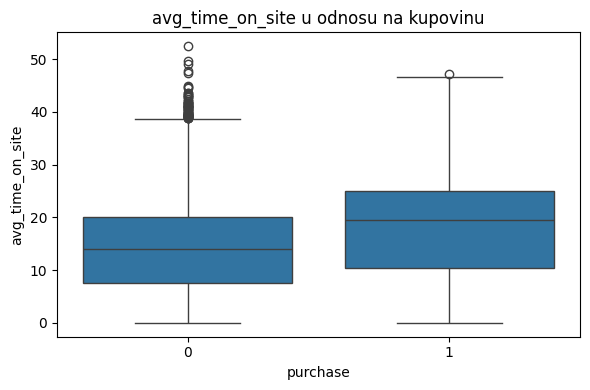

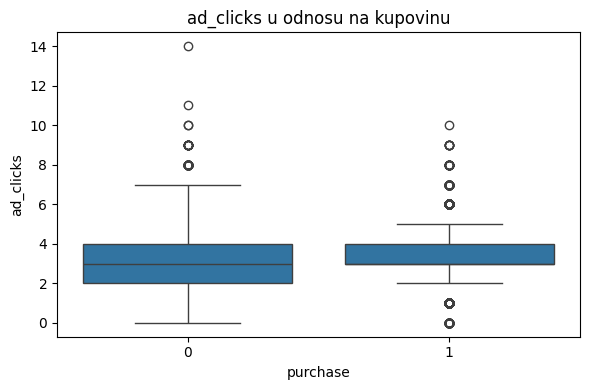

In [10]:
for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x='purchase', y=col, data = df)
  plt.title(f"{col} u odnosu na kupovinu")
  plt.tight_layout()
  plt.show()



Korelacija i heatmap:

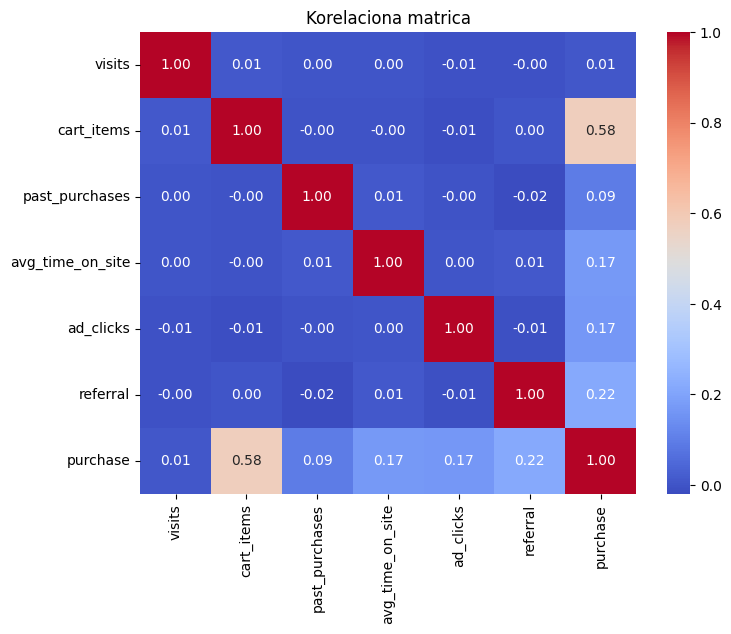

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Korelaciona matrica")
plt.show()

In [12]:
print(df.groupby('purchase')[num_cols].mean())

             visits  cart_items  past_purchases  avg_time_on_site  ad_clicks
purchase                                                                    
0         10.006702    1.506634        4.910200         14.400021   2.812492
1         10.053564    3.370224        5.589208         18.094048   3.468688


Priprema podataka

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [14]:
X = df.drop('purchase', axis=1)
y = df['purchase']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#skaliranje:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




Treniranje modela:

In [15]:
#xgboost model

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train)

#predikcija:
y_pred_xgb = xgb.predict(X_test_scaled)

#evaluacija

print("ACCURACY: ", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))






ACCURACY:  0.992

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1492
           1       0.99      0.98      0.98       508

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

Confusion Matrix:
 [[1486    6]
 [  10  498]]


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:11:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


feature importance

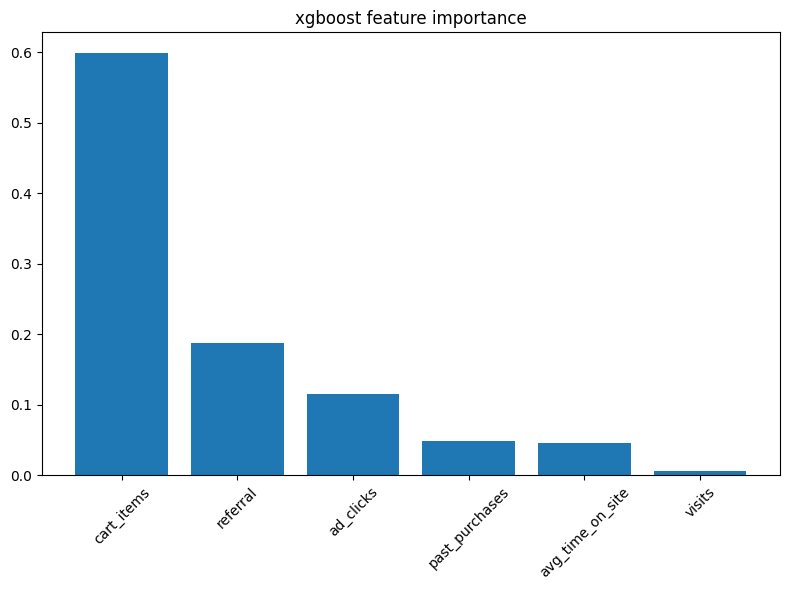

In [17]:
importances = xgb.feature_importances_
features = X.columns
indices = importances.argsort()[::-1]

plt.figure(figsize=(8,6))
plt.title("xgboost feature importance")
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()





svm model:

In [18]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Accuracy: ", accuracy_score(y_test, y_pred_svm))
print("Classification report: ", classification_report(y_test, y_pred_svm))
print("Confusion matrix: \n", confusion_matrix(y_test, y_pred_svm))

Accuracy:  0.9575
Classification report:                precision    recall  f1-score   support

           0       0.97      0.98      0.97      1492
           1       0.93      0.90      0.92       508

    accuracy                           0.96      2000
   macro avg       0.95      0.94      0.94      2000
weighted avg       0.96      0.96      0.96      2000

Confusion matrix: 
 [[1457   35]
 [  50  458]]


roc-auc:

In [19]:
from sklearn.metrics import roc_auc_score

y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]
auc_svm  = roc_auc_score(y_test, y_prob_svm)
print("SVM AUC Score: ", auc_svm)

SVM AUC Score:  0.9828811403601361


mlpclassifier

In [20]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64, 32),
                    activation='relu',
                    solver='adam',
                    max_iter=200,
                    random_state=42)

mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)
print("Accuracy: ", accuracy_score(y_test, y_pred_svm))
print("Classification report: \n", classification_report(y_test, y_pred_mlp))
print("Confusion matrix: \n", confusion_matrix(y_test, y_pred_mlp))



Accuracy:  0.9575
Classification report: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1492
           1       0.97      0.97      0.97       508

    accuracy                           0.99      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000

Confusion matrix: 
 [[1477   15]
 [  13  495]]


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


roc-auc za mlp

In [21]:
from sklearn.metrics import roc_auc_score

y_prob_mlp = mlp.predict_proba(X_test_scaled)[:, 1]
auc_mlp = roc_auc_score(y_test, y_prob_mlp)
print("Neural Network AUC Score: ", auc_mlp)

Neural Network AUC Score:  0.9934400793734564


Poredjenje svih modela

In [22]:
from sklearn.metrics import roc_curve, auc

# Verovatnoće
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]
y_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
y_proba_mlp = mlp.predict_proba(X_test_scaled)[:, 1]

# ROC krive
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)

# AUC vrednosti
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_svm = auc(fpr_svm, tpr_svm)
auc_mlp = auc(fpr_mlp, tpr_mlp)

print("=== Accuracy ===")
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))
print("SVM:    ", accuracy_score(y_test, y_pred_svm))
print("MLP:    ", accuracy_score(y_test, y_pred_mlp))

print("\n=== AUC Scores ===")
print("XGBoost AUC:", auc_xgb)
print("SVM AUC:    ", auc_svm)
print("MLP AUC:    ", auc_mlp)


=== Accuracy ===
XGBoost: 0.992
SVM:     0.9575
MLP:     0.986

=== AUC Scores ===
XGBoost AUC: 0.9938807498258428
SVM AUC:     0.9828811403601361
MLP AUC:     0.9934400793734564


Sve roc krive:

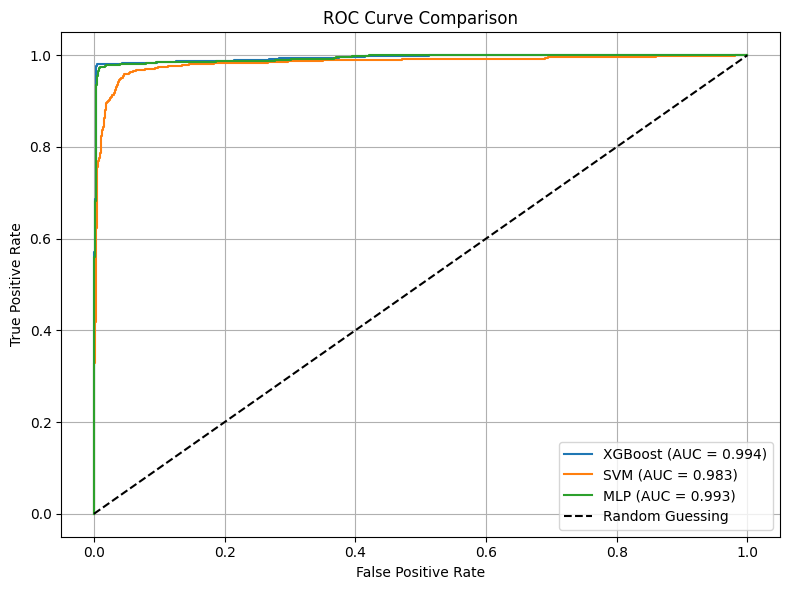

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc_mlp:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Pogresno klasifikovani primeri za sve modele:

In [24]:
# Pretvaramo test skup nazad u DataFrame da možemo lakše čitati
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
X_test_df['true_label'] = y_test.values

# XGBoost
X_test_df['xgb_pred'] = y_pred_xgb
wrong_xgb = X_test_df[X_test_df['true_label'] != X_test_df['xgb_pred']]
print("Pogrešne klasifikacije – XGBoost (prvih 5):")
print(wrong_xgb.head())

# SVM
X_test_df['svm_pred'] = y_pred_svm
wrong_svm = X_test_df[X_test_df['true_label'] != X_test_df['svm_pred']]
print("\nPogrešne klasifikacije – SVM (prvih 5):")
print(wrong_svm.head())

# MLP
X_test_df['mlp_pred'] = y_pred_mlp
wrong_mlp = X_test_df[X_test_df['true_label'] != X_test_df['mlp_pred']]
print("\nPogrešne klasifikacije – MLP (prvih 5):")
print(wrong_mlp.head())


Pogrešne klasifikacije – XGBoost (prvih 5):
       visits  cart_items  past_purchases  avg_time_on_site  ad_clicks  \
92   1.582537   -0.693182       -0.666445         -1.327807   1.171145   
217 -0.008872   -1.398890        0.918443         -0.452295   0.002629   
272  0.627691    0.718235       -1.617378         -0.533363   0.586887   
523  0.309410    0.012526        0.918443         -0.521387   0.002629   
739 -0.008872    0.718235        1.552398          0.235775  -1.165887   

     referral  true_label  xgb_pred  
92   1.548700           0         1  
217  1.548700           1         0  
272  1.548700           0         1  
523  1.548700           1         0  
739 -0.645703           1         0  

Pogrešne klasifikacije – SVM (prvih 5):
       visits  cart_items  past_purchases  avg_time_on_site  ad_clicks  \
4   -0.008872    0.012526        1.235420          0.635143   0.002629   
27   1.264255    1.423943       -1.617378          0.788888   0.002629   
72   0.627691    0.7

Cuvanje najboljeg modela

In [25]:
import joblib

joblib.dump(xgb, "best_model_xgboost.pkl")
print("Najbolji model je sačuvan kao 'best_model_xgboost.pkl'")


Najbolji model je sačuvan kao 'best_model_xgboost.pkl'
